# VQA Pipeline: CNN Perception + Symbolic Compositional Reasoning

A hybrid system for Visual Question Answering on a synthetic SHAPES dataset.

**Architecture:**
- **Stage 1 — Visual Perception (CNN):** Split each 30×30 image into a 3×3 grid of 10×10 cells. A shallow CNN classifies each non-empty cell into shape ∈ {circle, square, triangle} and color ∈ {red, green, blue}. Training labels are generated via a calibrated heuristic.
- **Stage 2 — Query Parsing:** Recursive-descent parser converts parenthesised prefix queries into nested-tuple ASTs.
- **Stage 3 — Compositional Reasoning:** Rule-based recursive executor evaluates the AST over detected objects, implementing spatial relations (left_of, right_of, above, below) and the logical operator `is`.

---
**Dataset Sizes Supported:** `tiny` · `small` · `medium` · `large`

## Cell 1 — Imports & Reproducibility

In [1]:
import csv
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports OK')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

c:\Users\Subhanshu Gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK
PyTorch: 2.11.0+cpu
CUDA available: False


## Cell 2 — Constants & Configuration

In [2]:
# ── Class definitions ───────────────────────────────────────────────────────
SHAPES       = ['circle', 'square', 'triangle']
COLORS       = ['red', 'green', 'blue']
SHAPE_TO_IDX = {s: i for i, s in enumerate(SHAPES)}
COLOR_TO_IDX = {c: i for i, c in enumerate(COLORS)}

# ── Dataset split sizes to iterate over ─────────────────────────────────────
SIZES = ['tiny', 'small', 'medium', 'large']

# ── File name templates (adjust paths if needed) ─────────────────────────────
# Training files:  train.{size}.input.npy  /  train.{size}.query  /  train.{size}.output
# Test files:      test.input.npy          /  test.query          /  test.output
TRAIN_IMAGE_FILE = lambda size: f'train.{size}.input.npy'
TRAIN_QUERY_FILE = lambda size: f'train.{size}.query'
TRAIN_LABEL_FILE = lambda size: f'train.{size}.output'
TEST_IMAGE_FILE  = 'test.input.npy'
TEST_QUERY_FILE  = 'test.query'
TEST_LABEL_FILE  = 'test.output'

# ── Heuristic: empirically-verified square profiles that fill-ratio misclassifies ──
_SQUARE_OVERRIDE_PROFILES = frozenset({
    (4, 8, 8, 8, 8, 8, 8, 4),
    (6, 8, 8, 10, 10, 8, 8, 6),
    (4, 7, 8, 8, 8, 8, 7, 4),
    (4, 8, 8, 8, 8, 8, 7, 4),
    (2, 6, 8, 8, 10, 10, 8, 8, 6, 2),
    (2, 6, 8, 8, 10, 10, 8, 8, 6),
    (6, 8, 8, 9, 9, 8, 8, 6),
    (4, 7, 8, 8, 8, 8, 6, 4),
    (5, 8, 8, 8, 8, 8, 8, 4),
    (1, 6, 8, 8, 10, 10, 8, 8, 6),
})

print('Constants set.')
print('Shapes:', SHAPES)
print('Colors:', COLORS)
print('Dataset sizes:', SIZES)

Constants set.
Shapes: ['circle', 'square', 'triangle']
Colors: ['red', 'green', 'blue']
Dataset sizes: ['tiny', 'small', 'medium', 'large']


## Cell 3 — Load Data Helper & Visualise Sample 30×30 Images

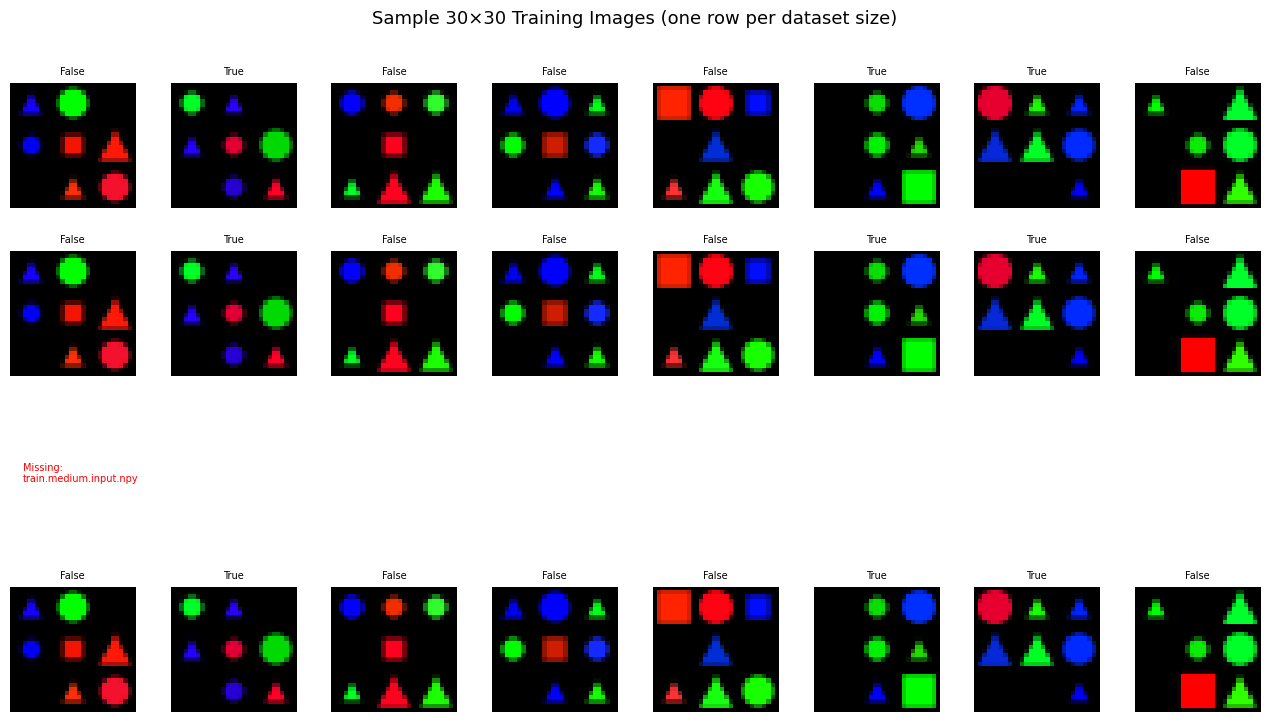

In [3]:
def load_split(size):
    """Load train images, queries, and labels for a given dataset size."""
    images = np.load(TRAIN_IMAGE_FILE(size))
    if images.max() > 1:
        images = images.astype(np.float32) / 255.0
    with open(TRAIN_QUERY_FILE(size)) as f:
        queries = [l.strip() for l in f]
    with open(TRAIN_LABEL_FILE(size)) as f:
        labels = [l.strip() == 'true' for l in f]
    return images, queries, labels


def load_test():
    """Load test images, queries, and labels."""
    images = np.load(TEST_IMAGE_FILE)
    if images.max() > 1:
        images = images.astype(np.float32) / 255.0
    with open(TEST_QUERY_FILE) as f:
        queries = [l.strip() for l in f]
    with open(TEST_LABEL_FILE) as f:
        labels = [l.strip() == 'true' for l in f]
    return images, queries, labels


# ── Quick preview: show 8 sample 30×30 images from each size ────────────────
N_SHOW = 8
fig, axes = plt.subplots(len(SIZES), N_SHOW, figsize=(N_SHOW * 1.6, len(SIZES) * 1.8))
fig.suptitle('Sample 30×30 Training Images (one row per dataset size)', fontsize=13, y=1.01)

for row_idx, size in enumerate(SIZES):
    try:
        imgs, qs, ls = load_split(size)
        axes[row_idx][0].set_ylabel(f'{size}\n({len(imgs)})', fontsize=9, rotation=0,
                                    labelpad=55, va='center')
        for col_idx in range(N_SHOW):
            ax = axes[row_idx][col_idx]
            ax.imshow(imgs[col_idx], interpolation='nearest')
            ax.set_title(str(ls[col_idx]), fontsize=7)
            ax.axis('off')
    except FileNotFoundError as e:
        axes[row_idx][0].text(0.1, 0.5, f'Missing:\n{e.filename}', fontsize=7, color='red')
        for ax in axes[row_idx]:
            ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 4 — Cell Extraction & Visualise 10×10 Patches

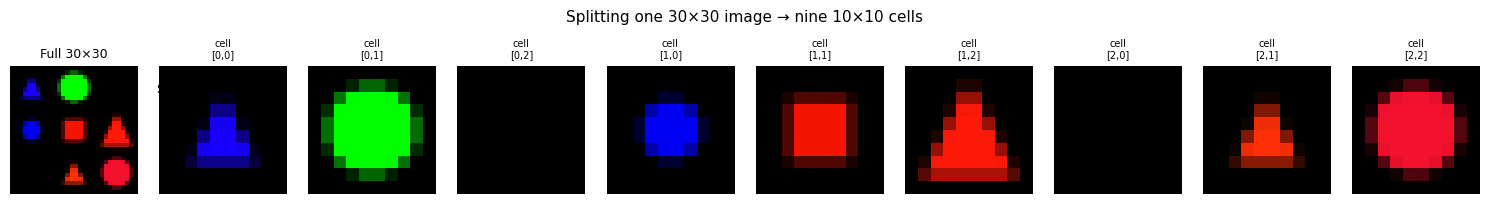

In [4]:
def extract_cells(image):
    """Split a 30×30 image into a flat list of 9 cells of 10×10 (row-major)."""
    cells = []
    for row in range(3):
        for col in range(3):
            cells.append(image[row * 10:(row + 1) * 10, col * 10:(col + 1) * 10, :])
    return cells


# ── Demo: pick one image and show its 3×3 grid of cells ─────────────────────
demo_imgs, _, _ = load_split(SIZES[0])          # use 'tiny' for the demo
demo_img        = demo_imgs[0]                  # first image
demo_cells      = extract_cells(demo_img)

fig, axes = plt.subplots(1, 10, figsize=(15, 2.2))
axes[0].imshow(demo_img, interpolation='nearest')
axes[0].set_title('Full 30×30', fontsize=9)
axes[0].axis('off')

# small arrow separator
axes[1].text(0.5, 0.5, '→\nsplit', ha='center', va='center', fontsize=11)
axes[1].axis('off')

for ci, cell in enumerate(demo_cells):
    ax = axes[ci + 1]
    ax.imshow(cell, interpolation='nearest')
    ax.set_title(f'cell\n[{ci//3},{ci%3}]', fontsize=7)
    ax.axis('off')

fig.suptitle('Splitting one 30×30 image → nine 10×10 cells', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 5 — Heuristic Labeller

In [5]:
def heuristic_label_cell(cell):
    """
    Classify a 10×10×3 cell by colour and shape using pixel analysis.
    Returns (shape, colour) or (None, None) for empty cells.
    """
    # Work in [0,255] range regardless of input dtype
    cell_u8 = (cell * 255).astype(np.float32) if cell.max() <= 1.0 else cell.astype(np.float32)

    mask     = cell_u8.sum(axis=2) > 10
    n_pixels = int(mask.sum())
    if n_pixels < 5:
        return None, None

    # Colour: dominant RGB channel
    mean_rgb = cell_u8[mask].mean(axis=0)
    color    = COLORS[int(np.argmax(mean_rgb))]

    # Shape: row-width profile
    row_widths = [int(mask[r].sum()) for r in range(10) if mask[r].sum() > 0]
    if len(row_widths) < 2:
        return None, None

    widths = np.array(row_widths)

    # Triangle: widths strictly increasing (non-decreasing with range > 1)
    if np.all(np.diff(widths) >= 0) and widths.max() - widths.min() > 1:
        return 'triangle', color

    # Calibrated square profile overrides
    if tuple(row_widths) in _SQUARE_OVERRIDE_PROFILES:
        return 'square', color

    # Fill-ratio: dense => square, sparse => circle
    fill_ratio = n_pixels / (len(widths) * int(widths.max()))
    if fill_ratio >= 0.90:
        return 'square', color

    return 'circle', color


def auto_label_cells(images):
    """
    Run heuristic labeller over all cells in *images*.
    Returns (cells_array [N,10,10,3], shape_ids [N], color_ids [N]).
    """
    all_cells, all_shapes, all_colors = [], [], []
    for img in images:
        for cell in extract_cells(img):
            shape, color = heuristic_label_cell(cell)
            if shape is not None:
                all_cells.append(cell)
                all_shapes.append(SHAPE_TO_IDX[shape])
                all_colors.append(COLOR_TO_IDX[color])
    return (np.array(all_cells, dtype=np.float32),
            np.array(all_shapes, dtype=np.int64),
            np.array(all_colors, dtype=np.int64))


print('Heuristic labeller defined.')

Heuristic labeller defined.


## Cell 6 — Visualise Heuristic Labels on Sample Cells

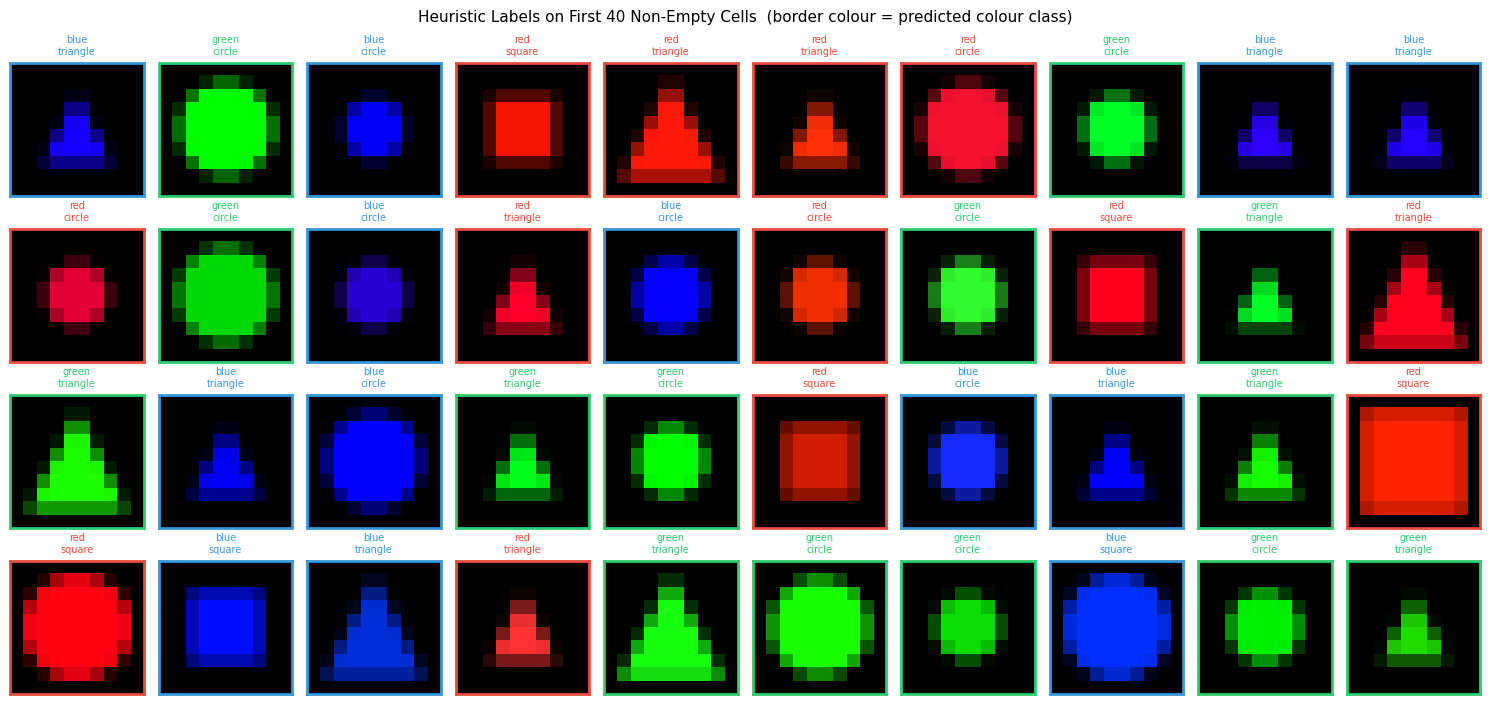

Shape distribution: {'circle': 83, 'square': 151, 'triangle': 126}
Color distribution: {'red': 104, 'green': 132, 'blue': 124}


In [6]:
# Run the labeller on the demo images and show the first N labelled cells
demo_cells_arr, demo_shapes, demo_colors = auto_label_cells(demo_imgs[:50])

N_VIS  = min(40, len(demo_cells_arr))
NCOLS  = 10
NROWS  = (N_VIS + NCOLS - 1) // NCOLS

# Colour coding for border
COLOR_HEX = {'red': '#e74c3c', 'green': '#2ecc71', 'blue': '#3498db'}

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 1.5, NROWS * 1.8))
axes = axes.flatten()

for i in range(N_VIS):
    ax    = axes[i]
    cell  = demo_cells_arr[i]
    shape = SHAPES[demo_shapes[i]]
    color = COLORS[demo_colors[i]]

    ax.imshow(cell, interpolation='nearest')
    ax.set_title(f'{color}\n{shape}', fontsize=7, color=COLOR_HEX.get(color, 'black'))
    for spine in ax.spines.values():
        spine.set_edgecolor(COLOR_HEX.get(color, 'gray'))
        spine.set_linewidth(2)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for i in range(N_VIS, len(axes)):
    axes[i].axis('off')

fig.suptitle(f'Heuristic Labels on First {N_VIS} Non-Empty Cells  '
             f'(border colour = predicted colour class)', fontsize=11)
plt.tight_layout()
plt.show()

# Distribution summary
print('Shape distribution:', {s: int((demo_shapes == i).sum()) for i, s in enumerate(SHAPES)})
print('Color distribution:', {c: int((demo_colors == i).sum()) for i, c in enumerate(COLORS)})

## Cell 7 — CNN Model Definition

In [7]:
class CellDataset(Dataset):
    """Wraps cell patches with their shape/colour labels."""
    def __init__(self, cells, shapes, colors):
        # cells already in [0,1] float32; permute to (N, C, H, W)
        self.cells  = torch.from_numpy(cells).permute(0, 3, 1, 2)
        self.shapes = torch.from_numpy(shapes)
        self.colors = torch.from_numpy(colors)

    def __len__(self):
        return len(self.cells)

    def __getitem__(self, idx):
        return self.cells[idx], self.shapes[idx], self.colors[idx]


class CellClassifier(nn.Module):
    """
    Shallow CNN with two classification heads:
      - shape_head  → one of {circle, square, triangle}
      - color_head  → one of {red, green, blue}
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.shape_head = nn.Linear(64, len(SHAPES))
        self.color_head = nn.Linear(64, len(COLORS))

    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.shape_head(feat), self.color_head(feat)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('CellClassifier defined.')
print('Using device:', DEVICE)

# Sanity-check forward pass
_dummy = torch.zeros(4, 3, 10, 10).to(DEVICE)
_m     = CellClassifier().to(DEVICE)
_sl, _cl = _m(_dummy)
print(f'Forward pass OK  →  shape_logits {tuple(_sl.shape)}, color_logits {tuple(_cl.shape)}')

CellClassifier defined.
Using device: cpu
Forward pass OK  →  shape_logits (4, 3), color_logits (4, 3)


## Cell 8 — CNN Training Function

In [8]:
def train_cnn(cells, shapes, colors, epochs=30, batch_size=256, lr=1e-3, verbose=True):
    """
    Train CellClassifier on heuristic-labelled cell patches.
    Returns (model, history_dict).
    """
    dataset   = CellDataset(cells, shapes, colors)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    model     = CellClassifier().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'loss': [], 'shape_acc': [], 'color_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = correct_s = correct_c = total = 0
        for bx, bs, bc in loader:
            bx, bs, bc = bx.to(DEVICE), bs.to(DEVICE), bc.to(DEVICE)
            sl, cl  = model(bx)
            loss    = criterion(sl, bs) + criterion(cl, bc)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * bx.size(0)
            correct_s  += (sl.argmax(1) == bs).sum().item()
            correct_c  += (cl.argmax(1) == bc).sum().item()
            total      += bx.size(0)

        ep_loss = total_loss / total
        ep_sa   = correct_s  / total
        ep_ca   = correct_c  / total
        history['loss'].append(ep_loss)
        history['shape_acc'].append(ep_sa)
        history['color_acc'].append(ep_ca)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'  Epoch {epoch:>3}/{epochs}  Loss {ep_loss:.4f}  '
                  f'Shape {ep_sa:.4f}  Color {ep_ca:.4f}')

    model.eval()
    return model, history


def plot_training_history(history, title='Training History'):
    """Plot loss + accuracy curves from a history dict."""
    epochs = range(1, len(history['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

    ax1.plot(epochs, history['loss'], 'b-o', markersize=3, label='Total Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['shape_acc'], 'g-o', markersize=3, label='Shape Acc')
    ax2.plot(epochs, history['color_acc'], 'r-o', markersize=3, label='Color Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Cell-Level Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


print('train_cnn() defined.')

train_cnn() defined.


## Cell 9 — CNN Inference (Perceive Image)

In [9]:
@torch.no_grad()
def perceive_image(model, image):
    """
    Run the CNN on a single 30×30 image.
    Returns a list of {shape, color, x, y} dicts for non-empty cells only.
    """
    cells     = extract_cells(image)
    non_empty = []
    positions = []

    for idx, cell in enumerate(cells):
        c_u8 = (cell * 255) if cell.max() <= 1.0 else cell
        if c_u8.sum(axis=2).max() > 10:
            non_empty.append(cell)
            row, col = divmod(idx, 3)
            positions.append((col, row))   # x = col, y = row

    if not non_empty:
        return []

    batch = (torch.from_numpy(np.array(non_empty, dtype=np.float32))
             .permute(0, 3, 1, 2)).to(DEVICE)

    sl, cl = model(batch)
    sp     = sl.argmax(1).cpu().numpy()
    cp     = cl.argmax(1).cpu().numpy()

    return [{'shape': SHAPES[sp[i]], 'color': COLORS[cp[i]],
             'x': positions[i][0], 'y': positions[i][1]}
            for i in range(len(non_empty))]


print('perceive_image() defined.')

perceive_image() defined.


## Cell 10 — Query Parser

In [10]:
def tokenize(query):
    """Tokenise a parenthesised prefix query string."""
    tokens, i = [], 0
    while i < len(query):
        ch = query[i]
        if ch in '()':
            tokens.append(ch); i += 1
        elif ch.isspace():
            i += 1
        else:
            j = i
            while j < len(query) and query[j] not in '() \t\n':
                j += 1
            tokens.append(query[i:j]); i = j
    return tokens


def _parse(tokens, pos):
    if tokens[pos] == '(':
        pos += 1
        op = tokens[pos]; pos += 1
        args = []
        while tokens[pos] != ')':
            arg, pos = _parse(tokens, pos)
            args.append(arg)
        return (op, *args), pos + 1
    return tokens[pos], pos + 1


def parse_query(query_str):
    """Convert a prefix query string into a nested-tuple AST."""
    tree, _ = _parse(tokenize(query_str.strip()), 0)
    return tree


# ── Quick parse demo ─────────────────────────────────────────────────────────
demo_queries = [
    '(is blue (left_of (right_of square)))',
    '(is red circle)',
    '(is triangle (above blue))',
]
print('Parser demos:')
for dq in demo_queries:
    print(f'  {dq!r}')
    print(f'    → {parse_query(dq)}')

Parser demos:
  '(is blue (left_of (right_of square)))'
    → ('is', 'blue', ('left_of', ('right_of', 'square')))
  '(is red circle)'
    → ('is', 'red', 'circle')
  '(is triangle (above blue))'
    → ('is', 'triangle', ('above', 'blue'))


## Cell 11 — Symbolic Executor

In [11]:
def execute(tree, objects):
    """
    Evaluate the query AST over the detected object list.

    Leaf nodes (strings) → set of object indices matching that attribute.
    Spatial operators    → filtered set of indices.
    'is'                 → boolean.
    """
    if isinstance(tree, str):
        return {i for i, o in enumerate(objects)
                if o['color'] == tree or o['shape'] == tree}

    op = tree[0]

    if op == 'is':
        attr       = tree[1]
        result_set = execute(tree[2], objects)
        return any(objects[i]['color'] == attr or objects[i]['shape'] == attr
                   for i in result_set)

    inner = execute(tree[1], objects)
    if not inner:
        return set()

    if op == 'left_of':
        return {i for i in range(len(objects))
                if any(objects[i]['x'] < objects[j]['x'] for j in inner)}
    if op == 'right_of':
        return {i for i in range(len(objects))
                if any(objects[i]['x'] > objects[j]['x'] for j in inner)}
    if op == 'above':
        return {i for i in range(len(objects))
                if any(objects[i]['y'] < objects[j]['y'] for j in inner)}
    if op == 'below':
        return {i for i in range(len(objects))
                if any(objects[i]['y'] > objects[j]['y'] for j in inner)}

    raise ValueError(f'Unknown operator: {op}')


print('Symbolic executor defined.')

Symbolic executor defined.


## Cell 12 — End-to-End Evaluate Helper

In [12]:
def evaluate(model, images, queries, labels=None, desc='Evaluating'):
    """
    Run the full pipeline (perceive → parse → execute) over a dataset split.
    Returns (predictions_list, accuracy_or_None).
    """
    model.eval()
    preds, correct = [], 0
    for img, q in tqdm(zip(images, queries), total=len(images), desc=desc, leave=False):
        objs = perceive_image(model, img)
        pred = bool(execute(parse_query(q), objs))
        preds.append(pred)
        if labels is not None and pred == labels[len(preds) - 1]:
            correct += 1
    acc = correct / len(images) if labels is not None else None
    return preds, acc


print('evaluate() defined.')

evaluate() defined.


## Cell 13 — Run Full Pipeline Across All 4 Dataset Sizes

For **each size** (tiny → small → medium → large):
1. Load train data & apply heuristic labelling
2. Train CNN (30 epochs)
3. Plot training curves
4. Evaluate on the shared test set
5. Print summary

Test set: 1024 images

  SIZE: TINY
  Train images : 64
  [2/4] Heuristic labelling ...
        465 non-empty cells labelled
        Shapes: {'circle': 106, 'square': 193, 'triangle': 166}
        Colors: {'red': 130, 'green': 169, 'blue': 166}
  [3/4] Training CNN (30 epochs) ...
  Epoch   1/30  Loss 1.9314  Shape 0.4129  Color 0.6344
  Epoch   5/30  Loss 1.2075  Shape 0.6387  Color 1.0000
  Epoch  10/30  Loss 0.9724  Shape 0.6882  Color 1.0000
  Epoch  15/30  Loss 0.8005  Shape 0.7699  Color 1.0000
  Epoch  20/30  Loss 0.6708  Shape 0.8129  Color 1.0000
  Epoch  25/30  Loss 0.5632  Shape 0.8151  Color 1.0000
  Epoch  30/30  Loss 0.4800  Shape 0.8516  Color 1.0000


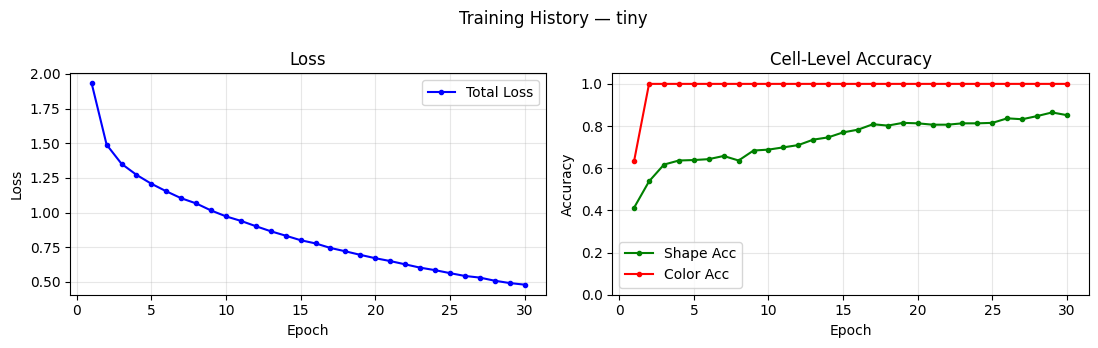

  [4/4] Evaluating on test set ...


  Test Accuracy: 0.8916  (913/1024)

  SIZE: SMALL
  Train images : 640
  [2/4] Heuristic labelling ...
        4665 non-empty cells labelled
        Shapes: {'circle': 1103, 'square': 2012, 'triangle': 1550}
        Colors: {'red': 1517, 'green': 1565, 'blue': 1583}
  [3/4] Training CNN (30 epochs) ...
  Epoch   1/30  Loss 1.3120  Shape 0.5711  Color 0.9415
  Epoch   5/30  Loss 0.4350  Shape 0.8898  Color 1.0000
  Epoch  10/30  Loss 0.1396  Shape 0.9681  Color 1.0000
  Epoch  15/30  Loss 0.0563  Shape 0.9878  Color 1.0000
  Epoch  20/30  Loss 0.0266  Shape 0.9959  Color 1.0000
  Epoch  25/30  Loss 0.0193  Shape 0.9961  Color 1.0000
  Epoch  30/30  Loss 0.0248  Shape 0.9929  Color 1.0000


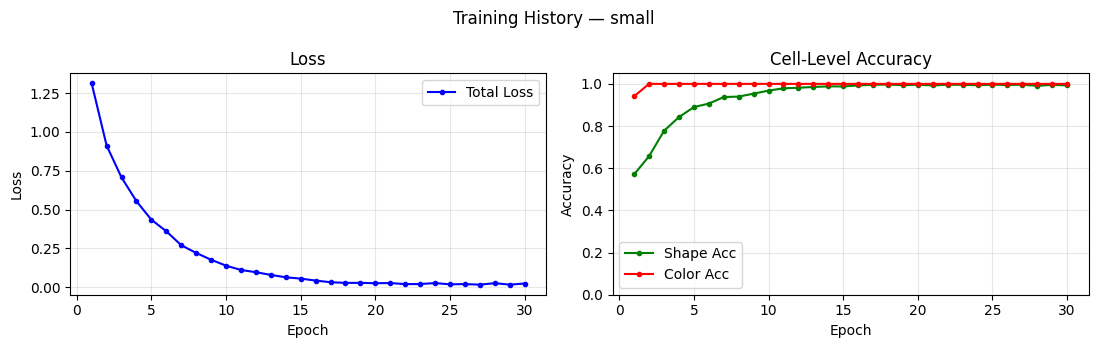

  [4/4] Evaluating on test set ...


  Test Accuracy: 0.9229  (945/1024)

  SIZE: MEDIUM
  [SKIP] File not found: train.medium.input.npy

  SIZE: LARGE
  Train images : 13568
  [2/4] Heuristic labelling ...
        98172 non-empty cells labelled
        Shapes: {'circle': 24202, 'square': 41243, 'triangle': 32727}
        Colors: {'red': 32699, 'green': 32839, 'blue': 32634}
  [3/4] Training CNN (30 epochs) ...
  Epoch   1/30  Loss 0.2514  Shape 0.9283  Color 0.9979
  Epoch   5/30  Loss 0.0089  Shape 0.9965  Color 1.0000
  Epoch  10/30  Loss 0.0056  Shape 0.9978  Color 1.0000
  Epoch  15/30  Loss 0.0058  Shape 0.9978  Color 1.0000
  Epoch  20/30  Loss 0.0045  Shape 0.9983  Color 1.0000
  Epoch  25/30  Loss 0.0040  Shape 0.9984  Color 1.0000
  Epoch  30/30  Loss 0.0035  Shape 0.9986  Color 1.0000


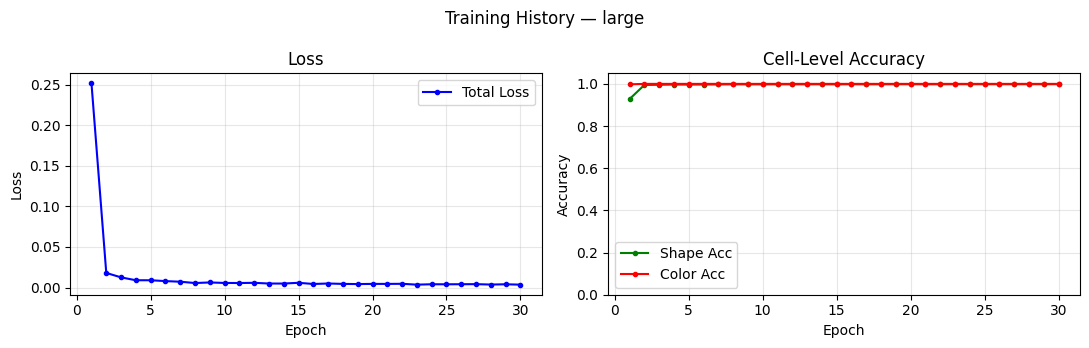

  [4/4] Evaluating on test set ...


  Test Accuracy: 0.9404  (963/1024)

✅ All sizes complete.


In [13]:
EPOCHS     = 30
BATCH_SIZE = 256

# Load test split once — shared across all size experiments
test_images, test_queries, test_labels = load_test()
print(f'Test set: {len(test_images)} images')

# Results accumulator for the final comparison table
all_results = {}

for size in SIZES:
    print('\n' + '=' * 60)
    print(f'  SIZE: {size.upper()}')
    print('=' * 60)

    # ── 1. Load data ──────────────────────────────────────────────
    try:
        train_images, train_queries, train_labels = load_split(size)
    except FileNotFoundError as e:
        print(f'  [SKIP] File not found: {e.filename}')
        continue
    print(f'  Train images : {len(train_images)}')

    # ── 2. Heuristic cell labelling ───────────────────────────────
    print('  [2/4] Heuristic labelling ...')
    cells, shape_ids, color_ids = auto_label_cells(train_images)
    print(f'        {len(cells)} non-empty cells labelled')
    print('        Shapes:', {s: int((shape_ids == i).sum()) for i, s in enumerate(SHAPES)})
    print('        Colors:', {c: int((color_ids == i).sum()) for i, c in enumerate(COLORS)})

    # ── 3. Train CNN ──────────────────────────────────────────────
    print(f'  [3/4] Training CNN ({EPOCHS} epochs) ...')
    model, history = train_cnn(cells, shape_ids, color_ids,
                               epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=True)
    plot_training_history(history, title=f'Training History — {size}')

    # ── 4. Evaluate ───────────────────────────────────────────────
    print('  [4/4] Evaluating on test set ...')
    test_preds, test_acc = evaluate(model, test_images, test_queries,
                                    test_labels, desc=f'Test [{size}]')
    n_correct = int(test_acc * len(test_images))
    print(f'  Test Accuracy: {test_acc:.4f}  ({n_correct}/{len(test_images)})')

    all_results[size] = {
        'train_n'   : len(train_images),
        'cells_n'   : len(cells),
        'test_acc'  : test_acc,
        'n_correct' : n_correct,
        'history'   : history,
        'model'     : model,
        'test_preds': test_preds,
    }

print('\n✅ All sizes complete.')

## Cell 14 — Results Comparison & Summary Plot

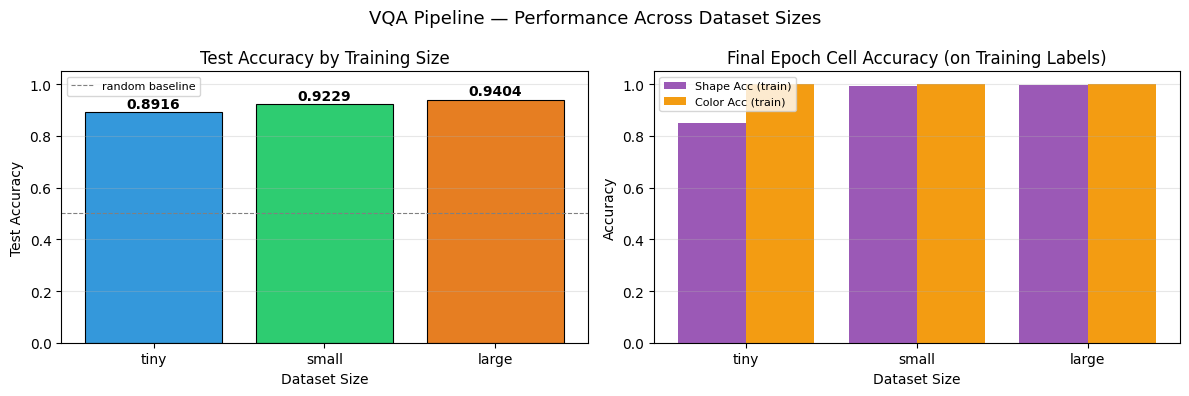


    Size  Train Imgs     Cells    Test Acc   Correct/Total
----------------------------------------------------------
    tiny          64       465      0.8916     913/1024  
   small         640      4665      0.9229     945/1024  
   large       13568     98172      0.9404     963/1024  


In [14]:
if not all_results:
    print('No results to display — check that data files are present.')
else:
    # ── Accuracy bar chart ────────────────────────────────────────────────────
    sizes_done = list(all_results.keys())
    accs       = [all_results[s]['test_acc'] for s in sizes_done]
    train_ns   = [all_results[s]['train_n']  for s in sizes_done]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    bars = ax1.bar(sizes_done, accs, color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'],
                   edgecolor='black', linewidth=0.8)
    for bar, acc in zip(bars, accs):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('Dataset Size'); ax1.set_ylabel('Test Accuracy')
    ax1.set_title('Test Accuracy by Training Size', fontsize=12)
    ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random baseline')
    ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

    # Final epoch shape accuracy per size
    final_shape_acc = [all_results[s]['history']['shape_acc'][-1] for s in sizes_done]
    final_color_acc = [all_results[s]['history']['color_acc'][-1] for s in sizes_done]
    x = np.arange(len(sizes_done))
    ax2.bar(x - 0.2, final_shape_acc, 0.4, label='Shape Acc (train)', color='#9b59b6')
    ax2.bar(x + 0.2, final_color_acc, 0.4, label='Color Acc (train)', color='#f39c12')
    ax2.set_xticks(x); ax2.set_xticklabels(sizes_done)
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel('Dataset Size'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Final Epoch Cell Accuracy (on Training Labels)', fontsize=12)
    ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('VQA Pipeline — Performance Across Dataset Sizes', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Printable table ───────────────────────────────────────────────────────
    print(f'\n{"Size":>8}  {"Train Imgs":>10}  {"Cells":>8}  '
          f'{"Test Acc":>10}  {"Correct/Total":>14}')
    print('-' * 58)
    for s in sizes_done:
        r = all_results[s]
        print(f'{s:>8}  {r["train_n"]:>10}  {r["cells_n"]:>8}  '
              f'{r["test_acc"]:>10.4f}  '
              f'{r["n_correct"]:>6}/{len(test_images):<6}')

## Cell 15 — Save Predictions & Best Model

In [15]:
if all_results:
    # Pick the best-performing size
    best_size = max(all_results, key=lambda s: all_results[s]['test_acc'])
    best      = all_results[best_size]
    print(f'Best size: {best_size}  (test acc = {best["test_acc"]:.4f})')

    # Save predictions for best model
    with open(f'predictions_{best_size}.txt', 'w') as f:
        for p in best['test_preds']:
            f.write('true\n' if p else 'false\n')
    print(f'Predictions saved → predictions_{best_size}.txt')

    # Save model weights
    torch.save(best['model'].state_dict(), f'cell_classifier_{best_size}.pth')
    print(f'Model saved       → cell_classifier_{best_size}.pth')

    # Also save predictions for every size
    for s in all_results:
        with open(f'predictions_{s}.txt', 'w') as f:
            for p in all_results[s]['test_preds']:
                f.write('true\n' if p else 'false\n')
    print('All per-size prediction files saved.')
else:
    print('No results to save.')

Best size: large  (test acc = 0.9404)
Predictions saved → predictions_large.txt
Model saved       → cell_classifier_large.pth
All per-size prediction files saved.
